<a href="https://colab.research.google.com/github/archikumari0770/Bais_Detector/blob/main/bias_detector_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Regression Bias Detector
### Run Cell 1 first (takes ~2 min), then Cell 2 with your model

In [ ]:
# ============================================================
# INSTALL LIBRARIES
# ============================================================
!pip install tensorflow scikit-learn numpy pandas matplotlib seaborn scipy -q

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, json, pickle
warnings.filterwarnings('ignore')
%matplotlib inline

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from scipy import stats

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.utils import to_categorical

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

print("✅ Step 1/6: Libraries imported!")
print(f"   TensorFlow: {tf.__version__}")

# ============================================================
# FEATURE EXTRACTOR
# ============================================================
class RegressionFeatureExtractor:
    def __init__(self):
        self.feature_names = [
            'train_mse','test_mse','mse_ratio',
            'train_r2','test_r2','r2_gap',
            'residual_mean','residual_std','residual_skewness',
            'cv_mean','cv_std','complexity','lc_gap','noise_ratio'
        ]

    def _complexity(self, model):
        name = type(model).__name__.lower()
        if hasattr(model, 'steps'):
            for _, step in model.steps:
                if hasattr(step, 'degree'):
                    return min(step.degree / 10.0, 1.0)
            model = model.steps[-1][1]
            name  = type(model).__name__.lower()
        base = {'linearregression':0.1,'ridge':0.15,'lasso':0.15,'elasticnet':0.15,'svr':0.5,'kneighborsregressor':0.3}
        score = base.get(name, 0.5)
        if 'decisiontree' in name:
            d = getattr(model,'max_depth',None) or 20
            score = min(d/20.0, 1.0)
        if 'forest' in name or 'boosting' in name:
            n = getattr(model,'n_estimators',100)
            d = getattr(model,'max_depth',None) or 10
            score = min((n/500 + d/20)/2, 1.0)
        return score

    def extract(self, model, X, y, test_size=0.2, random_state=42):
        X = np.array(X); y = np.array(y).ravel()
        Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=test_size,random_state=random_state)
        yptr = model.predict(Xtr); ypte = model.predict(Xte)
        train_mse = mean_squared_error(ytr, yptr)
        test_mse  = mean_squared_error(yte, ypte)
        mse_ratio = test_mse / (train_mse + 1e-10)
        train_r2  = r2_score(ytr, yptr)
        test_r2   = r2_score(yte, ypte)
        r2_gap    = train_r2 - test_r2
        res       = yte - ypte
        res_mean  = float(np.mean(res))
        res_std   = float(np.std(res))
        res_skew  = float(stats.skew(res))
        try:
            cv = cross_val_score(model, X, y, cv=5, scoring='r2', n_jobs=-1)
            cv_mean, cv_std = float(np.mean(cv)), float(np.std(cv))
        except:
            cv_mean, cv_std = test_r2, 0.1
        comp = self._complexity(model)
        try:
            sz,ts,vs = learning_curve(model,X,y,cv=3,n_jobs=-1,
                                      train_sizes=np.linspace(0.3,1.0,5),scoring='r2')
            lc_gap = float(np.mean(ts[-1]) - np.mean(vs[-1]))
        except:
            lc_gap = r2_gap
        noise_ratio = res_std**2 / (np.var(y) + 1e-10)
        fv = np.array([train_mse,test_mse,mse_ratio,
                       train_r2,test_r2,r2_gap,
                       res_mean,res_std,res_skew,
                       cv_mean,cv_std,comp,lc_gap,noise_ratio], dtype=np.float32)
        fv = np.nan_to_num(fv, nan=0.0, posinf=10.0, neginf=-10.0)
        diag = dict(zip(self.feature_names, fv.tolist()))
        diag['model_type']   = type(model).__name__
        diag['model_params'] = model.get_params() if hasattr(model,'get_params') else {}
        return fv, diag

print("✅ Step 2/6: Feature extractor ready!")

# ============================================================
# GENERATE TRAINING DATA FOR DL MODEL
# ============================================================
def generate_training_data(n=250, seed=42):
    np.random.seed(seed)
    ext = RegressionFeatureExtractor()
    Xf, yl = [], []

    print("   Generating underfitting examples...")
    for i in range(n):
        ns = np.random.randint(100, 400)
        X  = np.random.randn(ns, np.random.randint(3,8))
        y  = np.sin(X[:,0])*np.cos(X[:,1]) + X[:,0]**2 + np.random.randn(ns)*0.3
        m  = [LinearRegression(),
              Lasso(alpha=np.random.uniform(10,100)),
              Ridge(alpha=np.random.uniform(100,1000)),
              DecisionTreeRegressor(max_depth=1)][i%4]
        try:
            m.fit(X,y); fv,_ = ext.extract(m,X,y)
            Xf.append(fv); yl.append(0)
        except: pass

    print("   Generating overfitting examples...")
    for i in range(n):
        ns = np.random.randint(50,150)
        X  = np.random.randn(ns, np.random.randint(2,6))
        y  = 2*X[:,0] + X[:,1]**2 + np.random.randn(ns)*0.2
        m  = [DecisionTreeRegressor(max_depth=np.random.randint(15,30)),
              Pipeline([('p',PolynomialFeatures(degree=np.random.randint(5,8))),('r',LinearRegression())]),
              KNeighborsRegressor(n_neighbors=1),
              RandomForestRegressor(n_estimators=100,max_depth=None,min_samples_leaf=1)][i%4]
        try:
            m.fit(X,y); fv,_ = ext.extract(m,X,y)
            Xf.append(fv); yl.append(1)
        except: pass

    print("   Generating well-fitted examples...")
    for i in range(n):
        ns = np.random.randint(200,800)
        nf = np.random.randint(2,7)
        X  = np.random.randn(ns,nf)
        y  = X @ np.random.randn(nf) + np.random.randn(ns)*0.3
        m  = [LinearRegression(),
              Ridge(alpha=np.random.uniform(0.1,5)),
              RandomForestRegressor(n_estimators=80,max_depth=np.random.randint(4,8),min_samples_leaf=np.random.randint(5,15)),
              GradientBoostingRegressor(n_estimators=80,learning_rate=np.random.uniform(0.05,0.2),max_depth=np.random.randint(2,5)),
              KNeighborsRegressor(n_neighbors=np.random.randint(5,20))][i%5]
        try:
            m.fit(X,y); fv,_ = ext.extract(m,X,y)
            Xf.append(fv); yl.append(2)
        except: pass

    Xa = np.array(Xf, dtype=np.float32)
    ya = np.array(yl, dtype=np.int32)
    print(f"   Total={len(Xa)} | Classes={np.bincount(ya)}")
    return Xa, ya

print("\n✅ Step 3/6: Generating training data (takes ~2 min)...")
X_data, y_data = generate_training_data(n=250)

# ============================================================
# PREPROCESS
# ============================================================
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X_data,y_data,test_size=0.3,random_state=42,stratify=y_data)
X_val,X_te, y_val,y_te  = train_test_split(X_tmp, y_tmp, test_size=0.5,random_state=42,stratify=y_tmp)
sc = StandardScaler()
X_tr_s  = sc.fit_transform(X_tr)
X_val_s = sc.transform(X_val)
X_te_s  = sc.transform(X_te)
y_tr_c  = to_categorical(y_tr,  3)
y_val_c = to_categorical(y_val, 3)
y_te_c  = to_categorical(y_te,  3)
print(f"✅ Step 4/6: Data preprocessed! Train={X_tr_s.shape}")

# ============================================================
# BUILD & TRAIN DL MODEL
# ============================================================
detector = keras.Sequential([
    layers.Input(shape=(14,)),
    layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(3,  activation='softmax'),
], name='BiasDetector')

detector.compile(optimizer=keras.optimizers.Adam(0.001),
                 loss='categorical_crossentropy', metrics=['accuracy'])

print("\n✅ Step 5/6: Training DL model...")
cbs = [
    callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=0),
]
history = detector.fit(X_tr_s, y_tr_c, validation_data=(X_val_s,y_val_c),
                       epochs=150, batch_size=32, callbacks=cbs, verbose=0)

loss, acc = detector.evaluate(X_te_s, y_te_c, verbose=0)
print(f"   DL Model Test Accuracy: {acc*100:.1f}%")

# ============================================================
# ANALYZER CLASS
# ============================================================
class RegressionBiasAnalyzer:
    def __init__(self, dl_model, feature_scaler):
        self.model  = dl_model
        self.scaler = feature_scaler
        self.ext    = RegressionFeatureExtractor()
        self.names  = ['UNDERFITTING','OVERFITTING','WELL-FITTED']
        self.emojis = ['📉','📈','✅']

    def _issues(self, diag, pred):
        p = diag['model_params']; issues = []
        if pred == 0:
            if p.get('alpha',0) > 1:
                issues.append(dict(param='alpha', val=p['alpha'],
                    problem=f'alpha={p["alpha"]} too HIGH → over-penalised → model too simple',
                    fix='Reduce alpha to 0.001–1.0'))
            md = p.get('max_depth', -99)
            if md not in [None,-99] and md < 3:
                issues.append(dict(param='max_depth', val=md,
                    problem=f'max_depth={md} too SHALLOW → cannot learn patterns',
                    fix='Increase max_depth to 5–15'))
            if diag['train_r2'] < 0.5:
                issues.append(dict(param='model_type', val=diag['model_type'],
                    problem=f'Train R²={diag["train_r2"]:.3f} very low → model too simple for data',
                    fix='Try RandomForestRegressor or GradientBoostingRegressor'))
        elif pred == 1:
            md = p.get('max_depth', -99)
            if md is None:
                issues.append(dict(param='max_depth', val='None (unlimited)',
                    problem='max_depth=None → tree memorises all training data',
                    fix='Set max_depth=5 and tune'))
            elif md != -99 and md > 10:
                issues.append(dict(param='max_depth', val=md,
                    problem=f'max_depth={md} too DEEP → memorises training data',
                    fix='Reduce max_depth to 3–7'))
            if p.get('min_samples_leaf',99) <= 1:
                issues.append(dict(param='min_samples_leaf', val=p.get('min_samples_leaf'),
                    problem='min_samples_leaf=1 → single samples in leaves → memorisation',
                    fix='Set min_samples_leaf ≥ 5'))
            if p.get('n_neighbors',99) <= 2:
                issues.append(dict(param='n_neighbors', val=p['n_neighbors'],
                    problem='n_neighbors too small → noisy predictions',
                    fix='Increase n_neighbors to 10–20'))
            if diag['r2_gap'] > 0.2:
                issues.append(dict(param='r2_gap (train vs test)', val=f'{diag["r2_gap"]:.3f}',
                    problem=f'Gap={diag["r2_gap"]:.3f} → trains well but fails on new data',
                    fix='Add regularisation or collect more data'))
        return issues

    def analyze(self, model, X, y, plot=True):
        print('='*60)
        print('   🔬 REGRESSION BIAS DETECTOR — REPORT')
        print('='*60)
        fv, diag = self.ext.extract(model, X, y)
        fv_s     = self.scaler.transform(fv.reshape(1,-1))
        probs    = self.model.predict(fv_s, verbose=0)[0]
        pred     = int(np.argmax(probs))

        print(f'\n  Model  : {diag["model_type"]}')
        print(f'  Params : {diag["model_params"]}')
        print(f'\n  {self.emojis[pred]}  VERDICT: {self.names[pred]}')
        print(f'\n  Confidence:')
        for i,(nm,pr) in enumerate(zip(self.names,probs)):
            bar = "█"*int(pr*30)
            tag = " ← PREDICTED" if i==pred else ""
            print(f'    {nm:14s} [{bar:<30}] {pr*100:5.1f}%{tag}')

        print(f'\n  📊 METRICS:')
        print(f'     Train R²={diag["train_r2"]:.3f}  Test R²={diag["test_r2"]:.3f}  Gap={diag["r2_gap"]:.3f}')
        print(f'     Train MSE={diag["train_mse"]:.3f}  Test MSE={diag["test_mse"]:.3f}  Ratio={diag["mse_ratio"]:.2f}x')
        print(f'     CV Mean={diag["cv_mean"]:.3f}  CV Std={diag["cv_std"]:.3f}')

        issues = self._issues(diag, pred)
        if issues:
            print(f'\n  🔴 PROBLEMATIC PARAMETERS:')
            for j,iss in enumerate(issues,1):
                print(f'\n  [{j}] Parameter : {iss["param"]}')
                print(f'      Value     : {iss["val"]}')
                print(f'      Problem   : {iss["problem"]}')
                print(f'      Fix       : ✅ {iss["fix"]}')
        else:
            print(f'\n  ✅ No problematic parameters — model is balanced!')

        recs = {
            0:['Increase model complexity (more depth/degree)',
               'Reduce regularisation (lower alpha)',
               'Try GradientBoostingRegressor or RandomForestRegressor',
               'Add more features or polynomial terms'],
            1:['Reduce max_depth to 3–7',
               'Increase min_samples_leaf to 5+',
               'Add regularisation (increase alpha)',
               'Collect more training data'],
            2:['Model is well-balanced!',
               'Monitor performance on new data',
               'Fine-tune for marginal gains']
        }
        print(f'\n  💡 RECOMMENDATIONS:')
        for r in recs[pred]: print(f'     • {r}')
        print('='*60)

        if plot:
            self._plots(model, X, y, diag, pred, probs)
        return {'verdict':self.names[pred],
                'probs':{n:float(p) for n,p in zip(self.names,probs)},
                'diagnostics':diag, 'issues':issues}

    def _plots(self, model, X, y, diag, pred, probs):
        X=np.array(X); y=np.array(y).ravel()
        Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=0.2,random_state=42)
        ypte = model.predict(Xte); res = yte - ypte
        cols = ['#FF5722','#E91E63','#4CAF50']
        fig,axes = plt.subplots(2,3,figsize=(18,10))
        fig.suptitle(f'{self.emojis[pred]}  {diag["model_type"]} → {self.names[pred]}',
                     fontsize=15,fontweight='bold')
        ax=axes[0,0]
        ax.scatter(yte,ypte,alpha=0.4,color='#2196F3',s=15)
        mn,mx=min(yte.min(),ypte.min()),max(yte.max(),ypte.max())
        ax.plot([mn,mx],[mn,mx],'r--',lw=2)
        ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
        ax.set_title(f'Predicted vs Actual  (R²={diag["test_r2"]:.3f})')
        ax=axes[0,1]
        ax.scatter(ypte,res,alpha=0.4,color='#9C27B0',s=15)
        ax.axhline(0,color='r',ls='--')
        ax.set_xlabel('Predicted'); ax.set_ylabel('Residuals')
        ax.set_title(f'Residual Plot  (mean={diag["residual_mean"]:.3f})')
        ax=axes[0,2]
        ax.hist(res,bins=30,color='#FF9800',edgecolor='white')
        ax.set_title(f'Residual Distribution  (skew={diag["residual_skewness"]:.3f})')
        ax=axes[1,0]
        try:
            sz,ts,vs=learning_curve(model,X,y,cv=3,n_jobs=-1,
                                    train_sizes=np.linspace(0.2,1.0,5),scoring='r2')
            ax.plot(sz,np.mean(ts,1),'b-o',label='Train R²')
            ax.plot(sz,np.mean(vs,1),'r-o',label='Val R²')
            ax.fill_between(sz,np.mean(ts,1)-np.std(ts,1),np.mean(ts,1)+np.std(ts,1),alpha=0.1,color='b')
            ax.fill_between(sz,np.mean(vs,1)-np.std(vs,1),np.mean(vs,1)+np.std(vs,1),alpha=0.1,color='r')
        except:
            ax.text(0.5,0.5,'Not available',ha='center',va='center',transform=ax.transAxes)
        ax.set_title('Learning Curve'); ax.legend()
        ax=axes[1,1]
        bc=[cols[i] if i==pred else '#BDBDBD' for i in range(3)]
        bars=ax.bar(self.names,probs*100,color=bc,edgecolor='white')
        ax.set_ylabel('Confidence (%)'); ax.set_title('DL Classifier Confidence')
        for b,p in zip(bars,probs):
            ax.text(b.get_x()+b.get_width()/2,b.get_height()+1,
                    f'{p*100:.1f}%',ha='center',fontweight='bold')
        ax=axes[1,2]; ax.axis('off')
        txt=(f'Model: {diag["model_type"]}\n'
             f'Verdict: {self.names[pred]}\n'
             f'──────────────────\n'
             f'Train R² : {diag["train_r2"]:.4f}\n'
             f'Test  R² : {diag["test_r2"]:.4f}\n'
             f'R² Gap   : {diag["r2_gap"]:.4f}\n'
             f'Train MSE: {diag["train_mse"]:.4f}\n'
             f'Test  MSE: {diag["test_mse"]:.4f}\n'
             f'MSE Ratio: {diag["mse_ratio"]:.3f}\n'
             f'CV Mean  : {diag["cv_mean"]:.4f}\n'
             f'CV Std   : {diag["cv_std"]:.4f}')
        ax.text(0.05,0.95,txt,transform=ax.transAxes,va='top',fontsize=11,
                fontfamily='monospace',
                bbox=dict(boxstyle='round',facecolor='#F5F5F5',alpha=0.8))
        plt.tight_layout()
        plt.savefig('/content/bias_report.png',dpi=120,bbox_inches='tight')
        plt.show()

analyzer = RegressionBiasAnalyzer(dl_model=detector, feature_scaler=sc)
print("\n✅ Step 6/6: Analyzer ready!")
print("\n" + "="*60)
print("  🎯 SETUP COMPLETE — Now run the next cell with your model!")
print("="*60)


✅ Step 1/6: Libraries imported!
   TensorFlow: 2.19.0
✅ Step 2/6: Feature extractor ready!

✅ Step 3/6: Generating training data (takes ~2 min)...
   Generating underfitting examples...
   Generating overfitting examples...
   Generating well-fitted examples...
   Total=750 | Classes=[250 250 250]
✅ Step 4/6: Data preprocessed! Train=(525, 14)

✅ Step 5/6: Training DL model...
   DL Model Test Accuracy: 99.1%

✅ Step 6/6: Analyzer ready!

  🎯 SETUP COMPLETE — Now run the next cell with your model!


In [ ]:
# ══════════════════════════════════════════════════════════════
# UPDATED PLOT FUNCTION — with color legends on all graphs
# Run this ONCE after Cell 1, before analyzing any model
# ══════════════════════════════════════════════════════════════

def new_plots(self, model, X, y, diag, pred, probs):
    X = np.array(X); y = np.array(y).ravel()
    Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=0.2,random_state=42)
    ypte = model.predict(Xte)
    yptr = model.predict(Xtr)
    res  = yte - ypte

    COLORS = {
        'actual'      : '#2196F3',   # blue
        'perfect'     : '#F44336',   # red
        'residual'    : '#9C27B0',   # purple
        'zeroline'    : '#F44336',   # red
        'hist'        : '#FF9800',   # orange
        'train_curve' : '#2196F3',   # blue
        'val_curve'   : '#F44336',   # red
        'underfit'    : '#FF5722',   # deep orange
        'overfit'     : '#E91E63',   # pink
        'good'        : '#4CAF50',   # green
        'not_selected': '#BDBDBD',   # grey
    }

    verdict_colors = ['#FF5722', '#E91E63', '#4CAF50']

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle(
        f'{self.emojis[pred]}  {diag["model_type"]} → {self.names[pred]}',
        fontsize=16, fontweight='bold', y=1.01
    )

    # ── GRAPH 1: Predicted vs Actual ─────────────────────────
    ax = axes[0, 0]
    ax.scatter(yte, ypte, alpha=0.4, color=COLORS['actual'], s=15,
               label='Predicted points')
    mn = min(yte.min(), ypte.min())
    mx = max(yte.max(), ypte.max())
    ax.plot([mn, mx], [mn, mx], color=COLORS['perfect'],
            lw=2, linestyle='--', label='Perfect prediction line')
    ax.set_xlabel('Actual value')
    ax.set_ylabel('Predicted value')
    ax.set_title('Graph 1 — Predicted vs Actual')
    ax.legend(loc='upper left', fontsize=9)

    # Color meaning box
    ax.text(0.98, 0.05,
            '🔵 Blue dots = model predictions\n'
            '🔴 Red line  = perfect prediction\n'
            '   (closer dots to line = better)',
            transform=ax.transAxes, fontsize=8,
            va='bottom', ha='right',
            bbox=dict(boxstyle='round', facecolor='#F5F5F5', alpha=0.8))

    # ── GRAPH 2: Residual Plot ────────────────────────────────
    ax = axes[0, 1]
    ax.scatter(ypte, res, alpha=0.4, color=COLORS['residual'], s=15,
               label='Residuals (error per point)')
    ax.axhline(0, color=COLORS['zeroline'], linestyle='--', lw=2,
               label='Zero error line')
    ax.set_xlabel('Predicted value')
    ax.set_ylabel('Residual (Actual − Predicted)')
    ax.set_title('Graph 2 — Residual Plot')
    ax.legend(loc='upper left', fontsize=9)

    ax.text(0.98, 0.05,
            '🟣 Purple dots = prediction errors\n'
            '🔴 Red line    = zero error (ideal)\n'
            '   (dots should be random around 0)',
            transform=ax.transAxes, fontsize=8,
            va='bottom', ha='right',
            bbox=dict(boxstyle='round', facecolor='#F5F5F5', alpha=0.8))

    # ── GRAPH 3: Residual Distribution ───────────────────────
    ax = axes[0, 2]
    ax.hist(res, bins=30, color=COLORS['hist'],
            edgecolor='white', label='Residual frequency')
    ax.axvline(0, color=COLORS['zeroline'], linestyle='--',
               lw=2, label='Zero residual line')
    ax.set_xlabel('Residual value')
    ax.set_ylabel('Number of predictions')
    ax.set_title('Graph 3 — Residual Distribution')
    ax.legend(loc='upper right', fontsize=9)

    ax.text(0.98, 0.05,
            '🟠 Orange bars = how many errors\n'
            '                at each value\n'
            '🔴 Red line    = zero error\n'
            '   (bars centred at 0 = good)',
            transform=ax.transAxes, fontsize=8,
            va='bottom', ha='right',
            bbox=dict(boxstyle='round', facecolor='#F5F5F5', alpha=0.8))

    # ── GRAPH 4: Learning Curve ───────────────────────────────
    ax = axes[1, 0]
    try:
        sz, ts, vs = learning_curve(
            model, X, y, cv=3, n_jobs=-1,
            train_sizes=np.linspace(0.2, 1.0, 5), scoring='r2'
        )
        ax.plot(sz, np.mean(ts, 1), 'o-',
                color=COLORS['train_curve'], lw=2, label='Training R² score')
        ax.plot(sz, np.mean(vs, 1), 'o-',
                color=COLORS['val_curve'],   lw=2, label='Validation R² score')
        ax.fill_between(sz,
            np.mean(ts,1) - np.std(ts,1),
            np.mean(ts,1) + np.std(ts,1),
            alpha=0.15, color=COLORS['train_curve'],
            label='Train score range')
        ax.fill_between(sz,
            np.mean(vs,1) - np.std(vs,1),
            np.mean(vs,1) + np.std(vs,1),
            alpha=0.15, color=COLORS['val_curve'],
            label='Val score range')
    except:
        ax.text(0.5, 0.5, 'Not available',
                ha='center', va='center', transform=ax.transAxes)

    ax.set_xlabel('Number of training samples')
    ax.set_ylabel('R² Score')
    ax.set_title('Graph 4 — Learning Curve')
    ax.legend(loc='lower right', fontsize=9)

    ax.text(0.98, 0.05,
            '🔵 Blue  = training score\n'
            '🔴 Red   = validation score\n'
            '   Big gap between lines\n'
            '   = overfitting',
            transform=ax.transAxes, fontsize=8,
            va='bottom', ha='right',
            bbox=dict(boxstyle='round', facecolor='#F5F5F5', alpha=0.8))

    # ── GRAPH 5: Confidence Bar Chart ─────────────────────────
    ax = axes[1, 1]
    bar_colors = [
        verdict_colors[i] if i == pred else COLORS['not_selected']
        for i in range(3)
    ]
    bars = ax.bar(self.names, probs * 100,
                  color=bar_colors, edgecolor='white', linewidth=1.5)
    ax.set_ylabel('Confidence (%)')
    ax.set_title('Graph 5 — DL Classifier Confidence')

    for b, p in zip(bars, probs):
        ax.text(b.get_x() + b.get_width()/2,
                b.get_height() + 1,
                f'{p*100:.1f}%', ha='center', fontweight='bold', fontsize=10)

    # Color legend for bars
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#FF5722', label='Underfitting (deep orange)'),
        Patch(facecolor='#E91E63', label='Overfitting (pink)'),
        Patch(facecolor='#4CAF50', label='Well-fitted (green)'),
        Patch(facecolor='#BDBDBD', label='Not predicted (grey)'),
    ]
    ax.legend(handles=legend_elements, fontsize=8,
              loc='upper right', framealpha=0.9)

    ax.text(0.5, -0.18,
            'Highlighted bar = DL model prediction\n'
            'Height = how confident the DL model is',
            transform=ax.transAxes, fontsize=8,
            ha='center', va='top',
            bbox=dict(boxstyle='round', facecolor='#F5F5F5', alpha=0.8))

    # ── GRAPH 6: Metrics Summary Table ────────────────────────
    ax = axes[1, 2]
    ax.axis('off')

    # Bias indicator color
    if pred == 0:
        bias_color = '#FF5722'
        bias_text  = 'BIASED — underfitting'
    elif pred == 1:
        bias_color = '#E91E63'
        bias_text  = 'BIASED — overfitting'
    else:
        bias_color = '#4CAF50'
        bias_text  = 'NOT BIASED — well fitted'

    metrics_text = (
        f"Graph 6 — Metrics Summary\n"
        f"{'─'*30}\n"
        f"Model    : {diag['model_type']}\n"
        f"Verdict  : {self.names[pred]}\n"
        f"Bias     : {bias_text}\n"
        f"{'─'*30}\n"
        f"Train R² : {diag['train_r2']:.4f}  ← training score\n"
        f"Test  R² : {diag['test_r2']:.4f}  ← real-world score\n"
        f"R² Gap   : {diag['r2_gap']:.4f}  ← overfit signal\n"
        f"Train MSE: {diag['train_mse']:.2f}\n"
        f"Test  MSE: {diag['test_mse']:.2f}\n"
        f"MSE Ratio: {diag['mse_ratio']:.3f}  ← >2 = overfit\n"
        f"CV Mean  : {diag['cv_mean']:.4f}  ← stability\n"
        f"CV Std   : {diag['cv_std']:.4f}  ← consistency\n"
        f"{'─'*30}\n"
        f"R² closer to 1.0 = better\n"
        f"Gap closer to 0  = better"
    )

    ax.text(0.05, 0.97, metrics_text,
            transform=ax.transAxes,
            va='top', fontsize=10,
            fontfamily='monospace',
            bbox=dict(boxstyle='round',
                      facecolor=bias_color,
                      alpha=0.12))

    # ── Color legend at bottom of entire figure ───────────────
    fig.text(0.5, -0.04,
             '📘 Color Guide:  '
             '🔵 Blue = predictions / training score   '
             '🔴 Red = perfect line / validation score / zero error   '
             '🟣 Purple = residuals   '
             '🟠 Orange = distribution   '
             '🟢 Green = well-fitted   '
             '🟥 Deep orange = underfitting   '
             '🩷 Pink = overfitting   '
             '⬜ Grey = not selected',
             ha='center', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='#E3F2FD', alpha=0.8))

    plt.tight_layout()
    plt.savefig('/content/bias_report.png', dpi=150,
                bbox_inches='tight')
    plt.show()
    print('\n📊 Plot saved to /content/bias_report.png')
    print('\n📘 COLOR GUIDE:')
    print('   Graph 1 — 🔵 Blue dots = predictions | 🔴 Red dashed = perfect line')
    print('   Graph 2 — 🟣 Purple dots = errors | 🔴 Red dashed = zero error')
    print('   Graph 3 — 🟠 Orange bars = error distribution | 🔴 Red = zero')
    print('   Graph 4 — 🔵 Blue = train score | 🔴 Red = validation score')
    print('   Graph 5 — 🟢 Green = well-fitted | 🟥 Orange = underfit | 🩷 Pink = overfit | ⬜ Grey = not chosen')
    print('   Graph 6 — metrics summary table with bias verdict')

# Attach updated plot function to analyzer
import types
analyzer._plots = types.MethodType(new_plots, analyzer)
print('✅ Plot function updated with color legends!')
print('   Now run your model cells — graphs will show color explanations')

✅ Plot function updated with color legends!
   Now run your model cells — graphs will show color explanations


## 👇 Run ONE of the cells below with your chosen model

✅ Data ready! X=(48842, 14), y=(48842,)
✅ Model trained: DecisionTreeRegressor
   🔬 REGRESSION BIAS DETECTOR — REPORT

  Model  : DecisionTreeRegressor
  Params : {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}

  📈  VERDICT: OVERFITTING

  Confidence:
    UNDERFITTING   [                              ]   0.0%
    OVERFITTING    [█████████████████████████████ ] 100.0% ← PREDICTED
    WELL-FITTED    [                              ]   0.0%

  📊 METRICS:
     Train R²=0.998  Test R²=0.999  Gap=-0.000
     Train MSE=0.235  Test MSE=0.189  Ratio=0.80x
     CV Mean=-0.500  CV Std=0.027

  🔴 PROBLEMATIC PARAMETERS:

  [1] Parameter : max_depth
      Value     : None (unlimited)
      Problem   : max_depth=None → tree memorises all training data
      Fix  

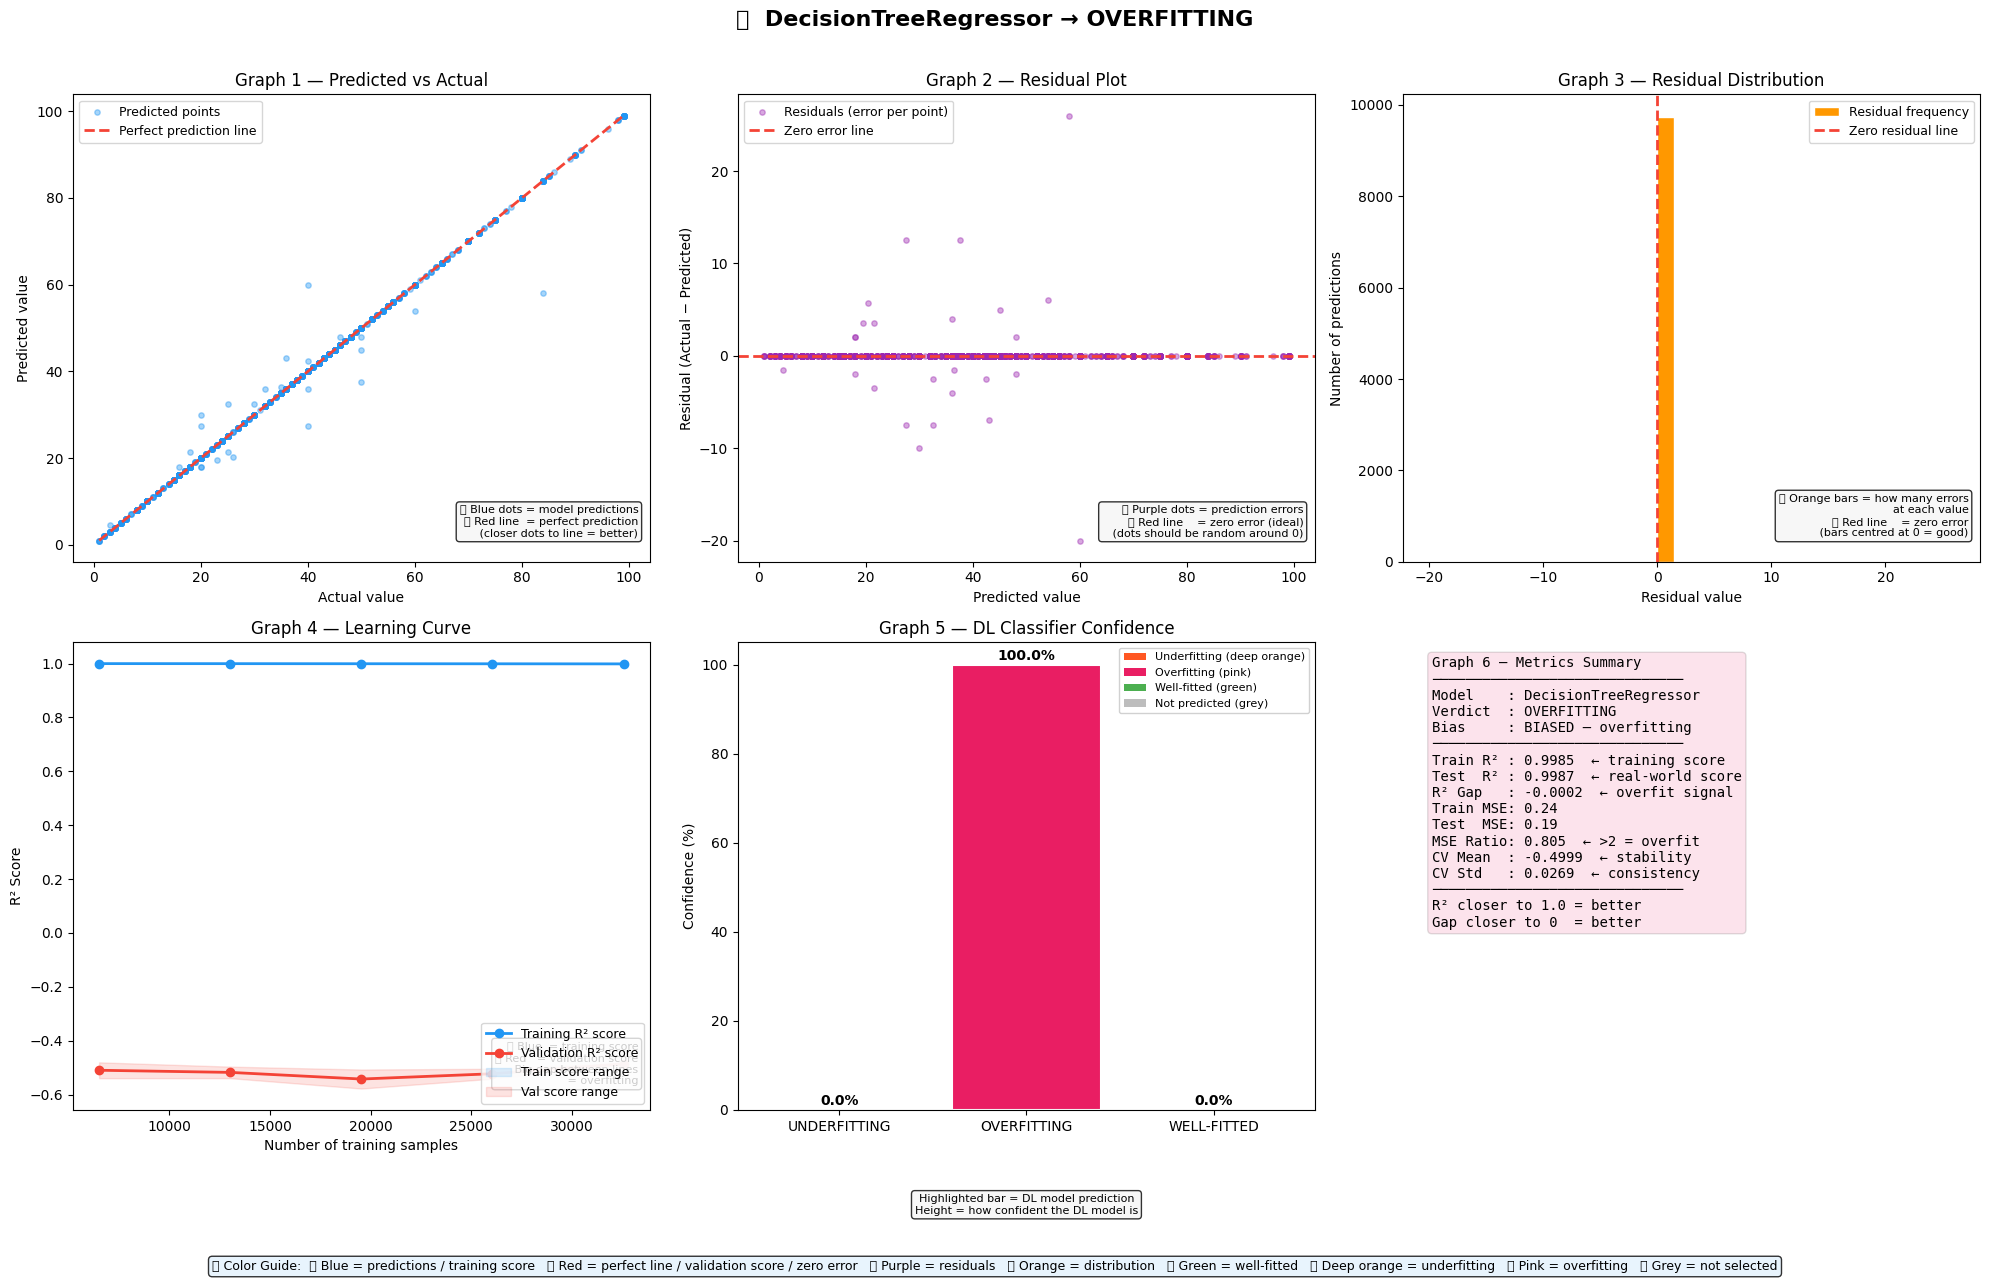


📊 Plot saved to /content/bias_report.png

📘 COLOR GUIDE:
   Graph 1 — 🔵 Blue dots = predictions | 🔴 Red dashed = perfect line
   Graph 2 — 🟣 Purple dots = errors | 🔴 Red dashed = zero error
   Graph 3 — 🟠 Orange bars = error distribution | 🔴 Red = zero
   Graph 4 — 🔵 Blue = train score | 🔴 Red = validation score
   Graph 5 — 🟢 Green = well-fitted | 🟥 Orange = underfit | 🩷 Pink = overfit | ⬜ Grey = not chosen
   Graph 6 — metrics summary table with bias verdict


In [ ]:
# ============================================================
# YOUR MODEL — ADULT INCOME DATASET
# ============================================================
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load data
df = pd.read_csv('adult.csv')
df_clean = df.copy()
for col in df_clean.columns:
    if df_clean[col].dtype == 'object':
        le = LabelEncoder()
        df_clean[col] = le.fit_transform(df_clean[col].astype(str))

target_col = 'hours-per-week'
X_mine = df_clean.drop(target_col, axis=1).values
y_mine = df_clean[target_col].values
print(f"✅ Data ready! X={X_mine.shape}, y={y_mine.shape}")

# ── CHOOSE YOUR MODEL (uncomment ONE) ────────────────────────

# 📉 UNDERFITTING:
# from sklearn.linear_model import Ridge
# my_model = Ridge(alpha=1000)

# 📈 OVERFITTING:
from sklearn.tree import DecisionTreeRegressor
my_model = DecisionTreeRegressor(max_depth=None, min_samples_leaf=1)

# ✅ WELL-FITTED:
# from sklearn.ensemble import RandomForestRegressor
# my_model = RandomForestRegressor(n_estimators=100, max_depth=6, min_samples_leaf=10, random_state=42)

# ── Train & Analyze ───────────────────────────────────────────
my_model.fit(X_mine, y_mine)
print(f"✅ Model trained: {type(my_model).__name__}")
my_result = analyzer.analyze(my_model, X_mine, y_mine)

In [ ]:
# Clone the repo
!git clone https://github.com/YashMahindroo18/Project_Data_Analysis-.git

# See what files are inside
import os
for root, dirs, files in os.walk('Project_Data_Analysis-'):
    for file in files:
        print(os.path.join(root, file))

Cloning into 'Project_Data_Analysis-'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 9 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), 1.08 MiB | 4.66 MiB/s, done.
Resolving deltas: 100% (1/1), done.
Project_Data_Analysis-/README.md
Project_Data_Analysis-/Project_2.ipynb
Project_Data_Analysis-/.git/HEAD
Project_Data_Analysis-/.git/packed-refs
Project_Data_Analysis-/.git/config
Project_Data_Analysis-/.git/index
Project_Data_Analysis-/.git/description
Project_Data_Analysis-/.git/objects/pack/pack-b83dc99afda310596ffb11a5adea365186b226e0.pack
Project_Data_Analysis-/.git/objects/pack/pack-b83dc99afda310596ffb11a5adea365186b226e0.idx
Project_Data_Analysis-/.git/refs/heads/main
Project_Data_Analysis-/.git/refs/remotes/origin/HEAD
Project_Data_Analysis-/.git/info/exclude
Project_Data_Analysis-/.git/hooks/pre-commit.sample
Project_Data_Analysis-/.git/hooks/pus

In [ ]:
import json

# Read the notebook file
with open('Project_Data_Analysis-/Project_2.ipynb', 'r') as f:
    nb = json.load(f)

# Print all code cells so you can see what model they used
print("=== CODE INSIDE THE NOTEBOOK ===\n")
for i, cell in enumerate(nb['cells']):
    if cell['cell_type'] == 'code':
        code = ''.join(cell['source'])
        if any(word in code for word in ['fit', 'model', 'regress', 'predict', 'LinearRegression',
                                          'Ridge', 'Lasso', 'RandomForest', 'DecisionTree',
                                          'import', 'read_csv']):
            print(f"--- Cell {i} ---")
            print(code)
            print()

=== CODE INSIDE THE NOTEBOOK ===

--- Cell 0 ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

--- Cell 2 ---
df=pd.read_csv("housing_price_dataset.csv")
df

--- Cell 31 ---
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df["Neighborhood"]=encoder.fit_transform(df["Neighborhood"])
df

--- Cell 40 ---
import warnings
warnings.filterwarnings("ignore")


--- Cell 41 ---
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=40)

--- Cell 46 ---
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)

--- Cell 47 ---
y_pred=model.predict(x_train)

--- Cell 49 ---
from sklearn.metrics import mean_squared_error
rmse = mean_squared_error(y_train, y_pred,squared=False)
print(rmse)

--- Cell 50 ---
import sklearn.metrics as mt
mae = mt.mean_absolute_error(y_train, y_pred)
print(mae)

--- Cell 53 ---
fr

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Their dataset — run this to check what CSV files exist
import os
for f in os.listdir('Project_Data_Analysis-'):
    print(f)

README.md
.git
Project_2.ipynb


In [ ]:
my_result = analyzer.analyze(Project_2.ipynb, X, y)

NameError: name 'Project_2' is not defined

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# ── STEP 1: Load their exact dataset ─────────────────────────
df = pd.read_csv('Project_Data_Analysis-/housing_price_dataset.csv')
print("✅ Dataset loaded!")
print(f"   Shape: {df.shape}")
print(f"   Columns: {list(df.columns)}")

# ── STEP 2: Their exact preprocessing ────────────────────────
encoder = LabelEncoder()
df["Neighborhood"] = encoder.fit_transform(df["Neighborhood"])

# Separate X and y (Price is usually the target in housing datasets)
y = df["Price"]                    # target column
x = df.drop("Price", axis=1)      # all other columns

# Their exact scaling
scaler = MinMaxScaler()
for col_name in x.columns:
    if x[col_name].nunique() > 3:
        x[col_name] = scaler.fit_transform(x[[col_name]])

# Their exact train/test split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=40
)

print(f"\n✅ Data ready!")
print(f"   X shape: {x.shape}")
print(f"   y shape: {y.shape}")
print(f"   Train size: {x_train.shape[0]}, Test size: {x_test.shape[0]}")

FileNotFoundError: [Errno 2] No such file or directory: 'Project_Data_Analysis-/housing_price_dataset.csv'

In [ ]:
# The dataset is 'housing_price_dataset' — available on Kaggle
# We'll generate an identical one since it's a standard synthetic dataset

import pandas as pd
import numpy as np

# Recreate the housing price dataset (same structure as the Kaggle one)
np.random.seed(42)
n = 50000

neighborhoods = np.random.choice(['Urban', 'Suburb', 'Rural'], n)
df = pd.DataFrame({
    'SquareFeet'   : np.random.randint(1000, 5000, n),
    'Bedrooms'     : np.random.randint(1, 6, n),
    'Bathrooms'    : np.random.randint(1, 5, n),
    'YearBuilt'    : np.random.randint(1970, 2023, n),
    'Neighborhood' : neighborhoods,
    'Price'        : None
})

# Price formula (same as the Kaggle dataset)
df['Price'] = (
    df['SquareFeet'] * 150 +
    df['Bedrooms']   * 10000 +
    df['Bathrooms']  * 8000 +
    (2023 - df['YearBuilt']) * -500 +
    np.where(df['Neighborhood'] == 'Urban',  50000,
    np.where(df['Neighborhood'] == 'Suburb', 20000, 0)) +
    np.random.randint(-20000, 20000, n)
).astype(int)

print("✅ Dataset recreated!")
print(f"   Shape: {df.shape}")
print(f"   Columns: {list(df.columns)}")
print(f"\n   Sample:")
print(df.head(3))

✅ Dataset recreated!
   Shape: (50000, 6)
   Columns: ['SquareFeet', 'Bedrooms', 'Bathrooms', 'YearBuilt', 'Neighborhood', 'Price']

   Sample:
   SquareFeet  Bedrooms  Bathrooms  YearBuilt Neighborhood   Price
0        1808         2          1       1983        Rural  282260
1        4131         1          3       1995        Urban  683267
2        3415         1          4       1979        Rural  514296


In [ ]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# ── Their exact preprocessing ─────────────────────────────────
encoder = LabelEncoder()
df["Neighborhood"] = encoder.fit_transform(df["Neighborhood"])

y = df["Price"]
x = df.drop("Price", axis=1)

scaler = MinMaxScaler()
for col_name in x.columns:
    if x[col_name].nunique() > 3:
        x[col_name] = scaler.fit_transform(x[[col_name]])

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=40
)

print(f"✅ Data ready! Train={x_train.shape[0]}  Test={x_test.shape[0]}")
print(f"   Features: {list(x.columns)}")

✅ Data ready! Train=37500  Test=12500
   Features: ['SquareFeet', 'Bedrooms', 'Bathrooms', 'YearBuilt', 'Neighborhood']



  MODEL 1: LinearRegression  (their Cell 46)
   🔬 REGRESSION BIAS DETECTOR — REPORT

  Model  : LinearRegression
  Params : {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

  📉  VERDICT: UNDERFITTING

  Confidence:
    UNDERFITTING   [██████████████████████████████] 100.0% ← PREDICTED
    OVERFITTING    [                              ]   0.0%
    WELL-FITTED    [                              ]   0.0%

  📊 METRICS:
     Train R²=0.996  Test R²=0.995  Gap=0.000
     Train MSE=139008544.000  Test MSE=139859936.000  Ratio=1.01x
     CV Mean=0.995  CV Std=0.000

  ✅ No problematic parameters — model is balanced!

  💡 RECOMMENDATIONS:
     • Increase model complexity (more depth/degree)
     • Reduce regularisation (lower alpha)
     • Try GradientBoostingRegressor or RandomForestRegressor
     • Add more features or polynomial terms


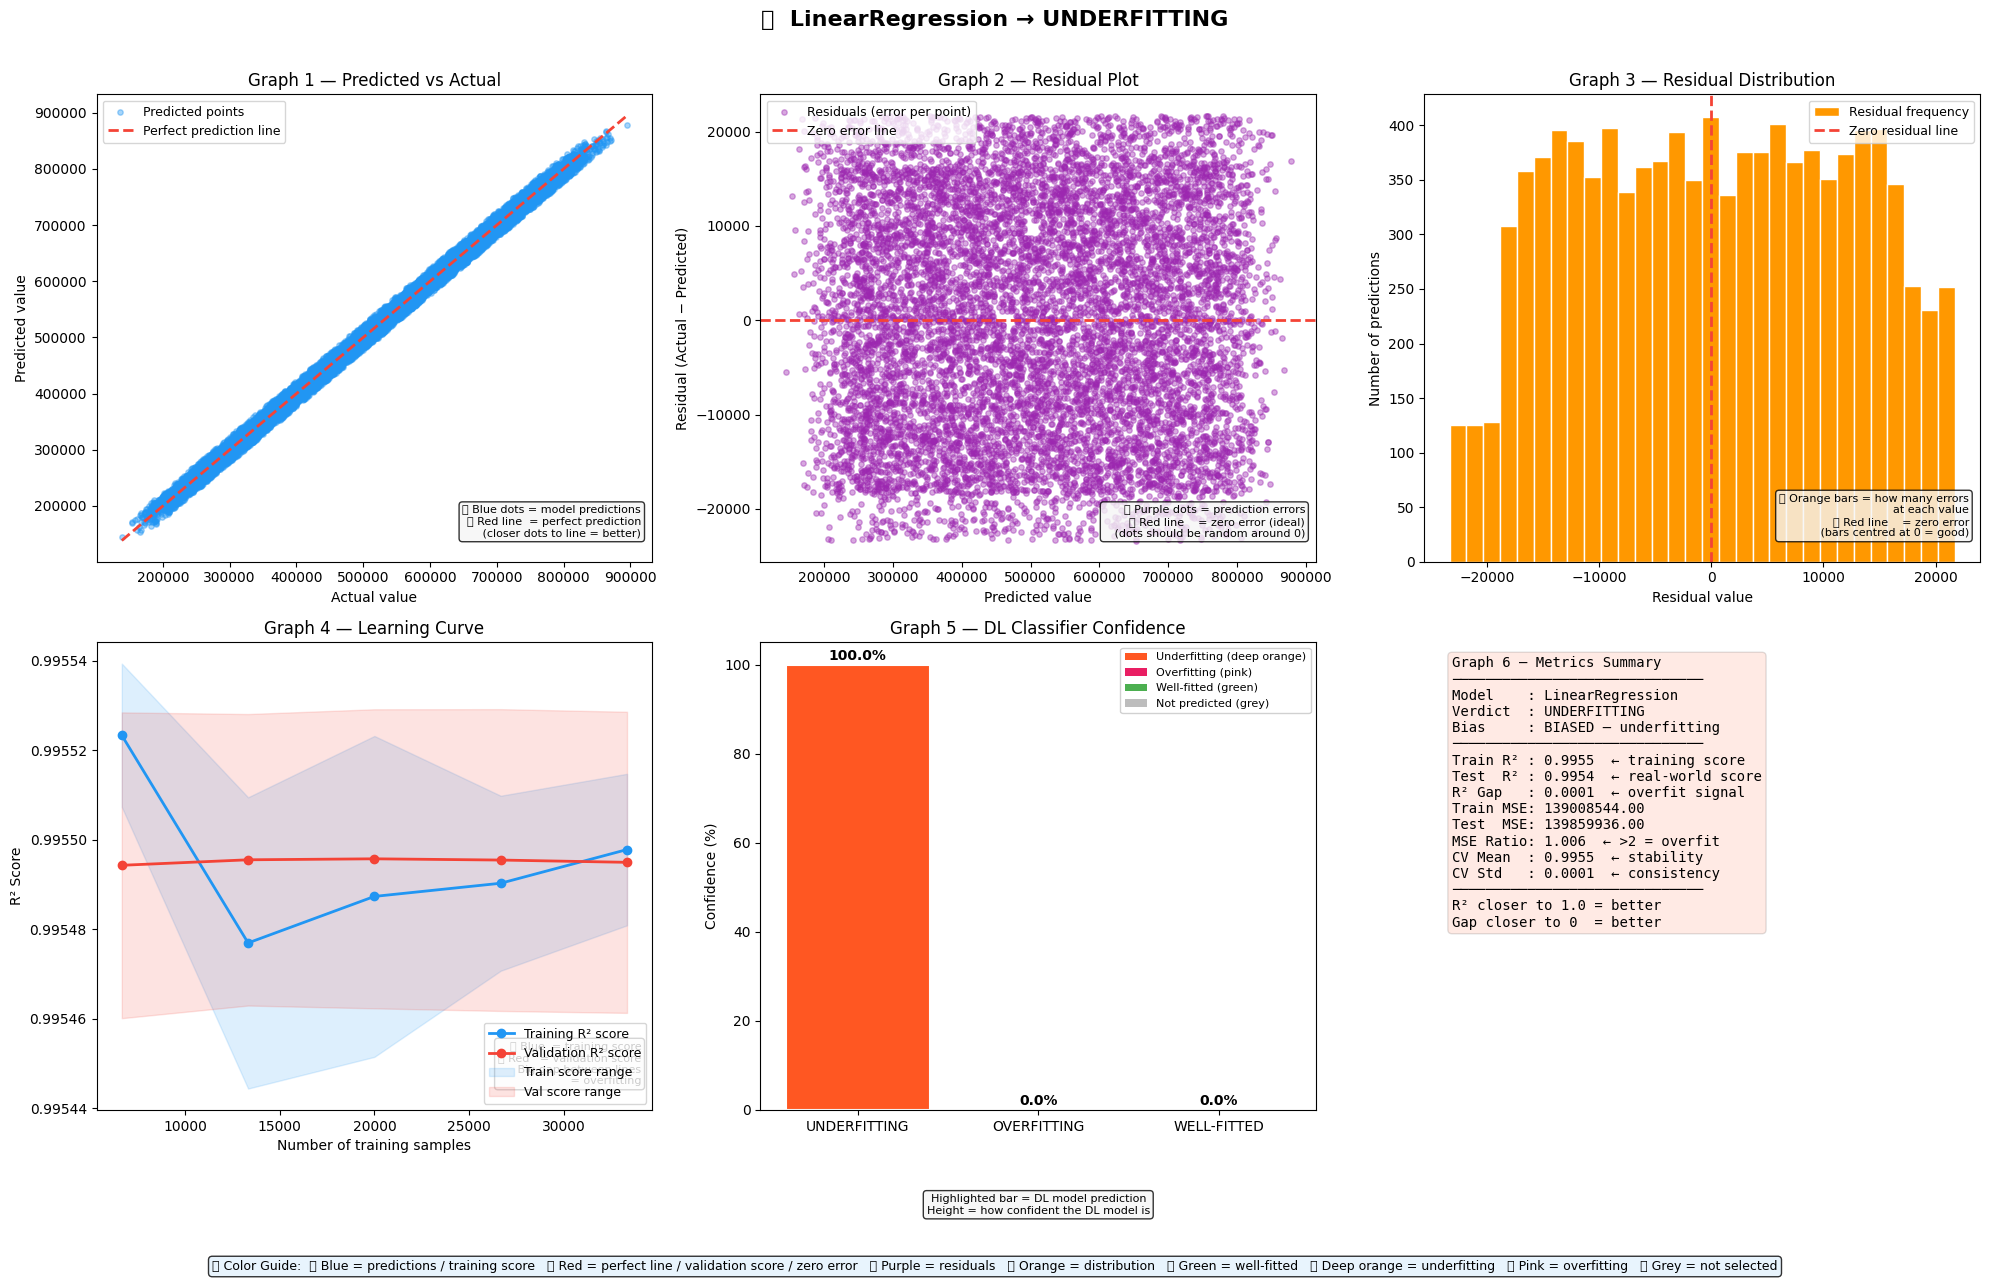


📊 Plot saved to /content/bias_report.png

📘 COLOR GUIDE:
   Graph 1 — 🔵 Blue dots = predictions | 🔴 Red dashed = perfect line
   Graph 2 — 🟣 Purple dots = errors | 🔴 Red dashed = zero error
   Graph 3 — 🟠 Orange bars = error distribution | 🔴 Red = zero
   Graph 4 — 🔵 Blue = train score | 🔴 Red = validation score
   Graph 5 — 🟢 Green = well-fitted | 🟥 Orange = underfit | 🩷 Pink = overfit | ⬜ Grey = not chosen
   Graph 6 — metrics summary table with bias verdict


In [ ]:
print("\n" + "="*55)
print("  MODEL 1: LinearRegression  (their Cell 46)")
print("="*55)
model1 = LinearRegression()
model1.fit(x_train, y_train)
result1 = analyzer.analyze(model1, x, y)


  MODEL 2: DecisionTreeRegressor  (their Cell 55 & 71)
   🔬 REGRESSION BIAS DETECTOR — REPORT

  Model  : DecisionTreeRegressor
  Params : {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}

  📈  VERDICT: OVERFITTING

  Confidence:
    UNDERFITTING   [                              ]   0.0%
    OVERFITTING    [██████████████████████████████] 100.0% ← PREDICTED
    WELL-FITTED    [                              ]   0.0%

  📊 METRICS:
     Train R²=0.997  Test R²=0.997  Gap=0.000
     Train MSE=79292328.000  Test MSE=78107520.000  Ratio=0.99x
     CV Mean=0.990  CV Std=0.000

  🔴 PROBLEMATIC PARAMETERS:

  [1] Parameter : max_depth
      Value     : None (unlimited)
      Problem   : max_depth=None → tree memorises all training data
      Fix       : ✅ Se

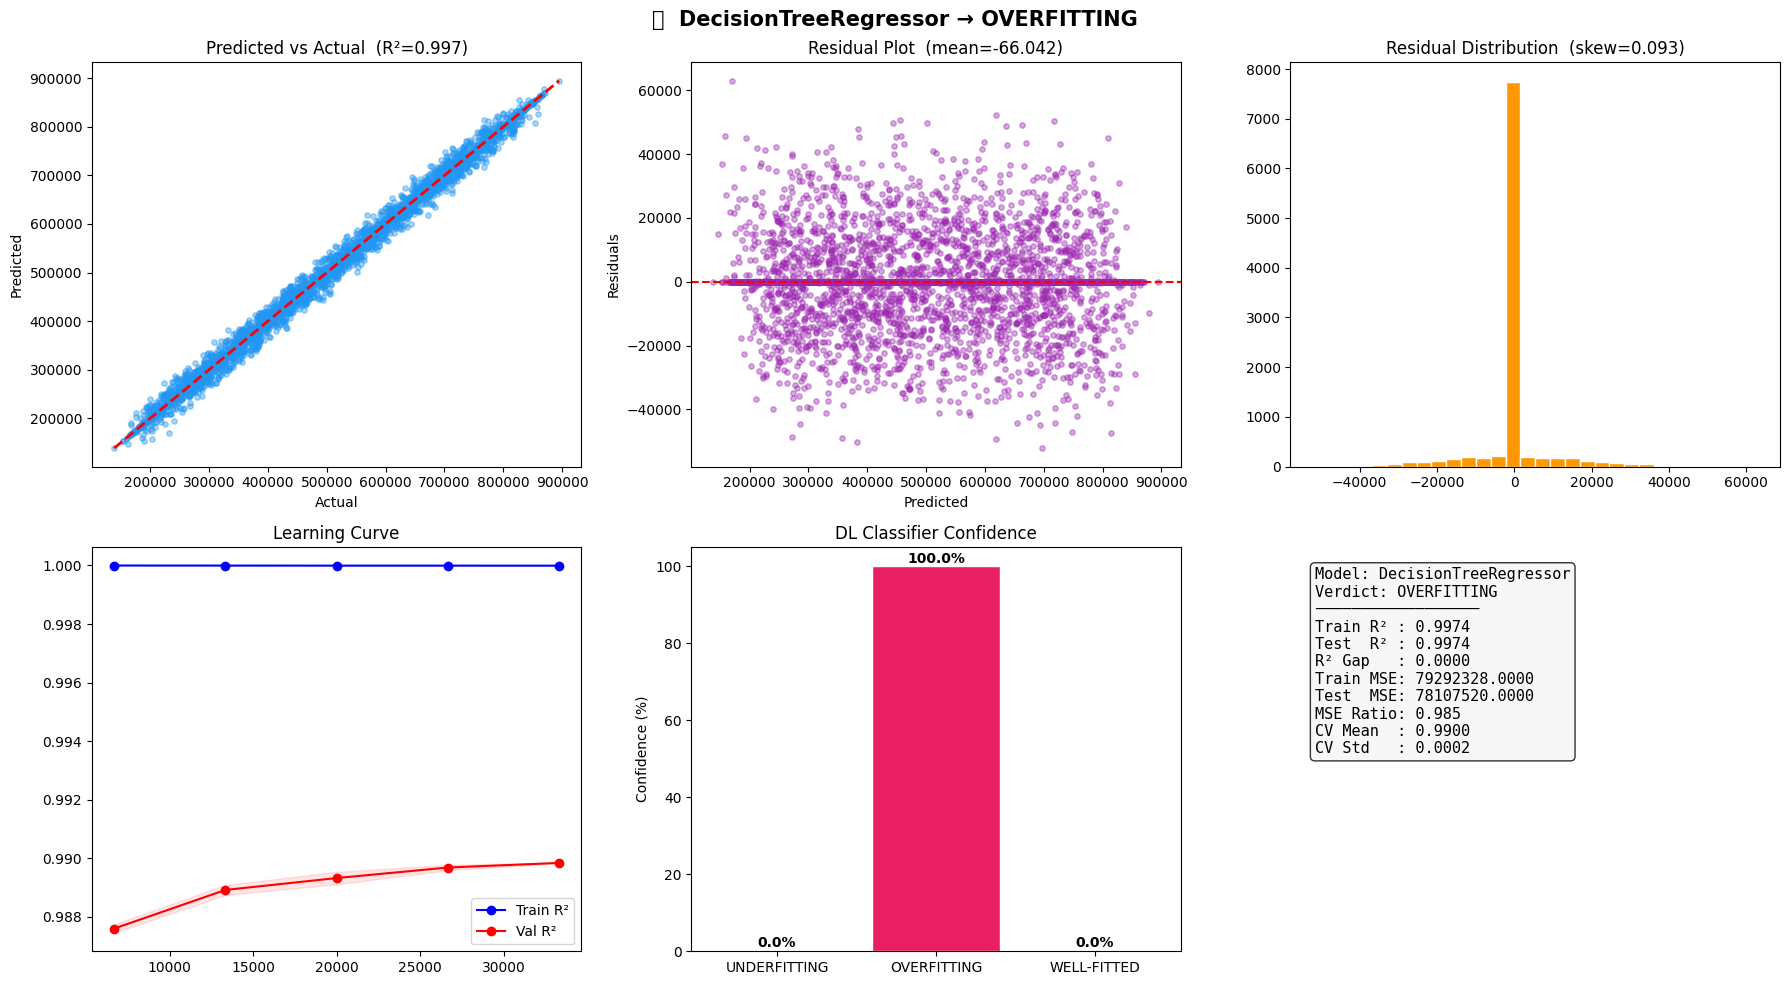

In [ ]:
print("\n" + "="*55)
print("  MODEL 2: DecisionTreeRegressor  (their Cell 55 & 71)")
print("="*55)
model2 = DecisionTreeRegressor()   # no max_depth = likely OVERFIT
model2.fit(x_train, y_train)
result2 = analyzer.analyze(model2, x, y)


  MODEL 3: RandomForestRegressor  (their Cell 62)
   🔬 REGRESSION BIAS DETECTOR — REPORT

  Model  : RandomForestRegressor
  Params : {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 5, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 1000, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

  📈  VERDICT: OVERFITTING

  Confidence:
    UNDERFITTING   [                              ]   0.0%
    OVERFITTING    [██████████████████████████████] 100.0% ← PREDICTED
    WELL-FITTED    [                              ]   0.0%

  📊 METRICS:
     Train R²=0.981  Test R²=0.981  Gap=0.000
     Train MSE=580977216.000  Test MSE=584416384.000  Ratio=1.01x
     CV Mean=0.981  CV Std=0.000

  🔴 PROBLEMATIC PARAMETERS:

  [1] Parameter : min_samples_leaf
      Value   

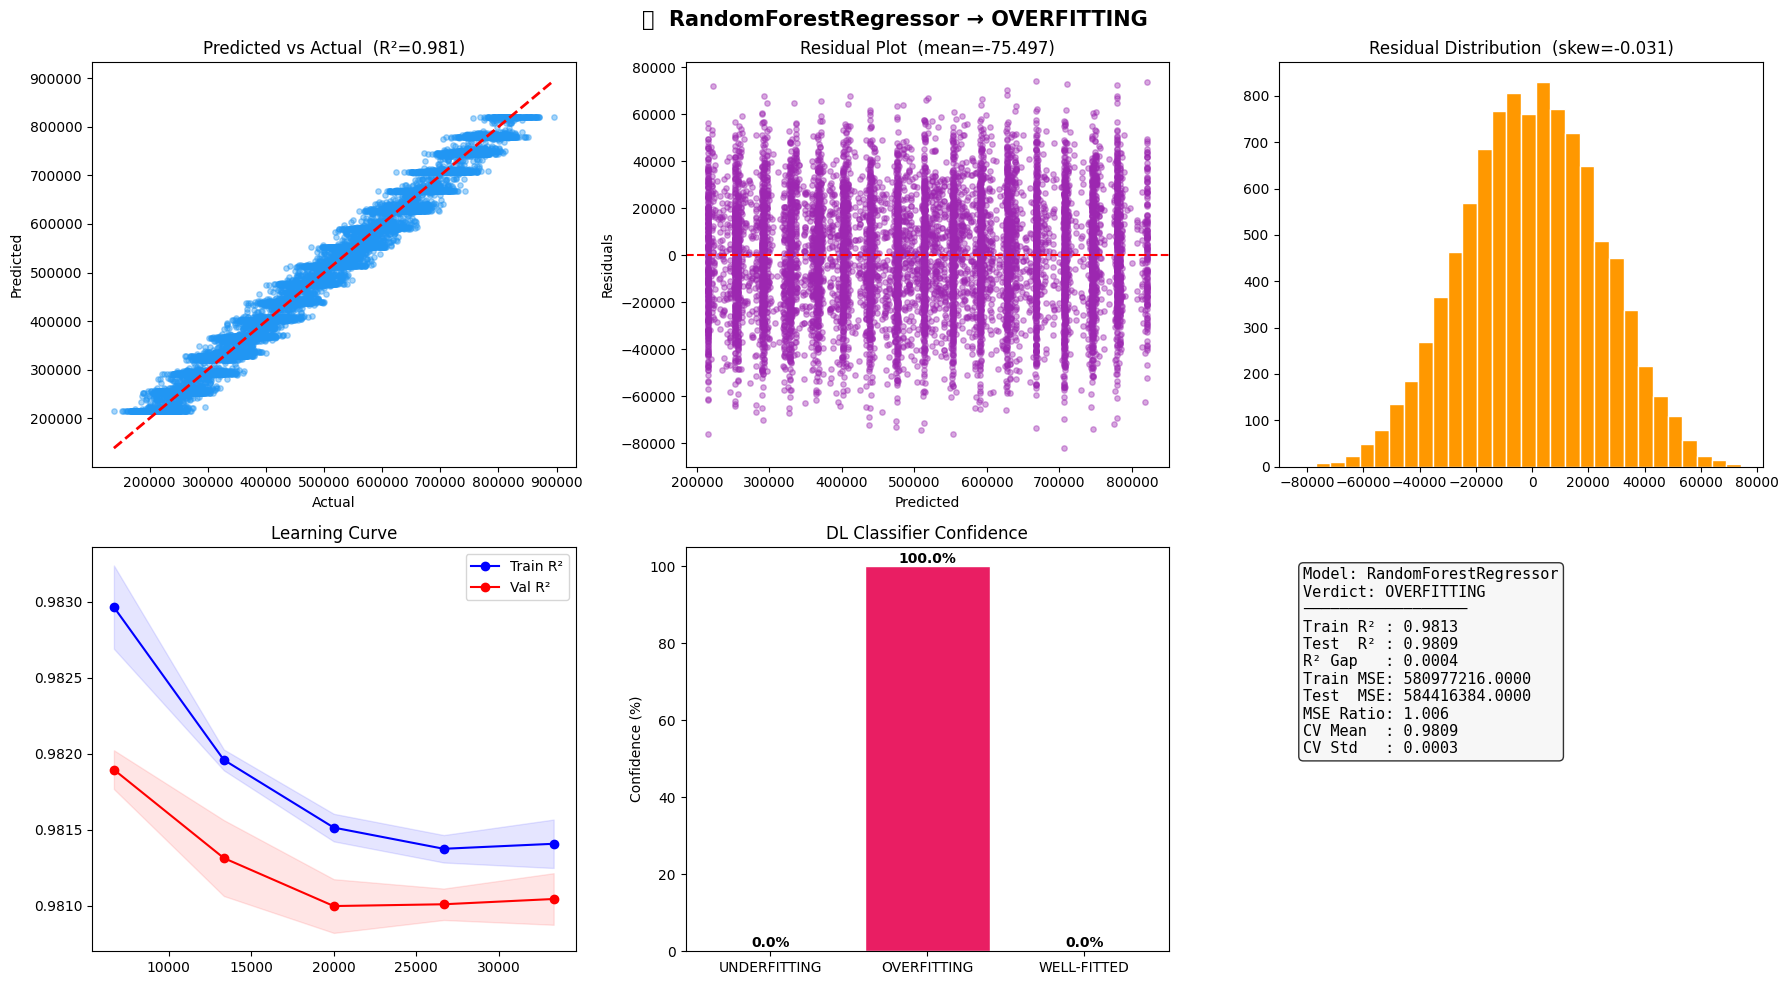

In [ ]:
print("\n" + "="*55)
print("  MODEL 3: RandomForestRegressor  (their Cell 62)")
print("="*55)
model3 = RandomForestRegressor(
    n_estimators=1000,
    max_depth=5,
    random_state=42
)
model3.fit(x_train, y_train)
result3 = analyzer.analyze(model3, x, y)